In [1]:
!git clone https://github.com/Htaaxx/ragas-evaluation.git
%cd ragas-evaluation


Cloning into 'ragas-evaluation'...
remote: Enumerating objects: 327, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 327 (delta 26), reused 35 (delta 18), pack-reused 277 (from 1)
Receiving objects: 100% (327/327), 25.97 MiB | 18.05 MiB/s, done.
Resolving deltas: 100% (116/116), done.
/kaggle/working/ragas-evaluation


In [2]:
!git checkout filtering-pipeline
!git pull

Branch 'filtering-pipeline' set up to track remote branch 'filtering-pipeline' from 'origin'.
Switched to a new branch 'filtering-pipeline'
Already up to date.


In [3]:
!pip install -r requirements.txt
!pip install ragas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.2/178.2 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.9/543.9 kB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 59.1 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing instal

In [4]:
%cd notebooks

/kaggle/working/ragas-evaluation/notebooks


# Answer Quality Filter: Training and Evaluation

**Objective:** Train a DeBERTa-v3-small binary classifier on labeled_asqa.csv
to accept correct answers and reject hallucinated ones, then evaluate against
a no-filter baseline on a held-out test set.

In [5]:
import sys, json, logging
import numpy as np
import pandas as pd
sys.path.append("..")

from src.filtering.data_split import load_and_split
from src.filtering.learned_filter import AnswerQualityClassifier, train_classifier
from src.filtering.filter_evaluator import FilterEvaluator

logging.basicConfig(level=logging.INFO)
SEED = 42

/usr/local/lib/python3.12/dist-packages/wrapt/importer.py:223: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  self.__wrapped__.exec_module(module)
RAGAS not installed. Install with: pip install ragas


## 1. Data Split

In [6]:
train_df, val_df, test_df = load_and_split("../data/asqa/labeled_asqa.csv", seed=SEED)
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"Label distribution (train): {train_df['label'].value_counts().to_dict()}")

INFO:src.filtering.data_split:Loaded 8706 samples from ../data/asqa/labeled_asqa.csv
INFO:src.filtering.data_split:Found 4353 unique base question IDs
INFO:src.filtering.data_split:Train: 5570 samples (pos=2785, neg=2785)
INFO:src.filtering.data_split:Val: 1394 samples (pos=697, neg=697)
INFO:src.filtering.data_split:Test: 1742 samples (pos=871, neg=871)


Train: 5570, Val: 1394, Test: 1742
Label distribution (train): {1: 2785, 0: 2785}


In [7]:
# Tổng số NaN mỗi cột
train_df.isna().sum()

id                  0
question            0
answer              0
context             0
supporting_facts    0
label               0
dtype: int64

In [8]:
val_df.isna().sum()

id                  0
question            0
answer              0
context             0
supporting_facts    0
label               0
dtype: int64

## 2. Train Classifier

In [9]:
import shutil
from pathlib import Path

model_dir = Path("../models/answer_filter")
# Force retrain to use fixed code (LayerNorm fix + stable hyperparams)
if model_dir.exists():
    shutil.rmtree(model_dir)
    print(f"Removed old model at {model_dir}, retraining with fixed code...")

model_dir = train_classifier(
    train_df, val_df,
    output_dir=str(model_dir),
)

INFO:src.filtering.learned_filter:Training config: {
  "model_name": "microsoft/deberta-v3-small",
  "model_path": "models/answer_filter",
  "threshold": 0.5,
  "max_length": 512,
  "batch_size": 16,
  "num_epochs": 5,
  "learning_rate": 1e-05,
  "warmup_ratio": 0.2,
  "weight_decay": 0.01,
  "max_grad_norm": 1.0,
  "label_smoothing": 0.1,
  "seed": 42
}
INFO:src.filtering.learned_filter:Model: microsoft/deberta-v3-small  ->  ../models/answer_filter
INFO:src.filtering.learned_filter:Train samples: 5570  Val samples: 1394
INFO:httpx:HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-small/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/deberta-v3-small/a36c739020e01763fe789b4b85e2df55d6180012/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/resolve-cache/models/microsoft/deberta-v3-small/a36c739020e01763fe789b4b85e2df55d6180012/config.json "

config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-small/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/deberta-v3-small/a36c739020e01763fe789b4b85e2df55d6180012/tokenizer_config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/resolve-cache/models/microsoft/deberta-v3-small/a36c739020e01763fe789b4b85e2df55d6180012/tokenizer_config.json "HTTP/1.1 200 OK"


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/microsoft/deberta-v3-small/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/microsoft/deberta-v3-small/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-small/resolve/main/spm.model "HTTP/1.1 302 Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/microsoft/deberta-v3-small/xet-read-token/a36c739020e01763fe789b4b85e2df55d6180012 "HTTP/1.1 200 OK"


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

INFO:src.filtering.learned_filter:Model saved to ../models/answer_filter


INFO:src.filtering.learned_filter:Training log saved to results/training_log.json


## 3. Threshold Tuning (Validation Set)

In [10]:
clf = AnswerQualityClassifier(str(model_dir))
evaluator = FilterEvaluator()

val_decisions = clf.predict_batch(
    val_df["question"].tolist(), val_df["answer"].tolist()
)
val_confidences = [d.confidence for d in val_decisions]
val_labels = val_df["label"].tolist()

sweep = []
for t in np.arange(0.1, 0.95, 0.05):
    preds = [c >= t for c in val_confidences]
    r = evaluator.evaluate(preds, val_labels)
    sweep.append({
        "threshold": round(float(t), 2),
        "f1": r.f1,
        "precision": r.precision,
        "recall": r.recall,
        "accuracy": r.accuracy,
        "rejection_recall": r.rejection_recall,
        "rejection_rate": r.rejection_rate,
    })

sweep_df = pd.DataFrame(sweep)
best_row = sweep_df.loc[sweep_df["f1"].idxmax()]
best_threshold = best_row["threshold"]
print(f"Best threshold: {best_threshold} (F1={best_row['f1']:.4f})")
sweep_df

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

INFO:src.filtering.learned_filter:AnswerQualityClassifier loaded from ../models/answer_filter (threshold=0.50, device=cuda)
INFO:src.filtering.filter_evaluator:Evaluation (n=1394): P=0.000 R=0.000 F1=0.000 Acc=0.500 RejR=1.000
INFO:src.filtering.filter_evaluator:Evaluation (n=1394): P=0.000 R=0.000 F1=0.000 Acc=0.500 RejR=1.000
INFO:src.filtering.filter_evaluator:Evaluation (n=1394): P=0.000 R=0.000 F1=0.000 Acc=0.500 RejR=1.000
INFO:src.filtering.filter_evaluator:Evaluation (n=1394): P=0.000 R=0.000 F1=0.000 Acc=0.500 RejR=1.000
INFO:src.filtering.filter_evaluator:Evaluation (n=1394): P=0.000 R=0.000 F1=0.000 Acc=0.500 RejR=1.000
INFO:src.filtering.filter_evaluator:Evaluation (n=1394): P=0.000 R=0.000 F1=0.000 Acc=0.500 RejR=1.000
INFO:src.filtering.filter_evaluator:Evaluation (n=1394): P=0.000 R=0.000 F1=0.000 Acc=0.500 RejR=1.000
INFO:src.filtering.filter_evaluator:Evaluation (n=1394): P=0.000 R=0.000 F1=0.000 Acc=0.500 RejR=1.000
INFO:src.filtering.filter_evaluator:Evaluation (n=13

Best threshold: 0.1 (F1=0.0000)


,threshold,f1,precision,recall,accuracy,rejection_recall,rejection_rate
0,0.10,0.0,0.0,0.0,0.5,1.0,1.0
1,0.15,0.0,0.0,0.0,0.5,1.0,1.0
2,0.20,0.0,0.0,0.0,0.5,1.0,1.0
3,0.25,0.0,0.0,0.0,0.5,1.0,1.0
4,0.30,0.0,0.0,0.0,0.5,1.0,1.0
5,0.35,0.0,0.0,0.0,0.5,1.0,1.0
6,0.40,0.0,0.0,0.0,0.5,1.0,1.0
7,0.45,0.0,0.0,0.0,0.5,1.0,1.0
8,0.50,0.0,0.0,0.0,0.5,1.0,1.0
9,0.55,0.0,0.0,0.0,0.5,1.0,1.0


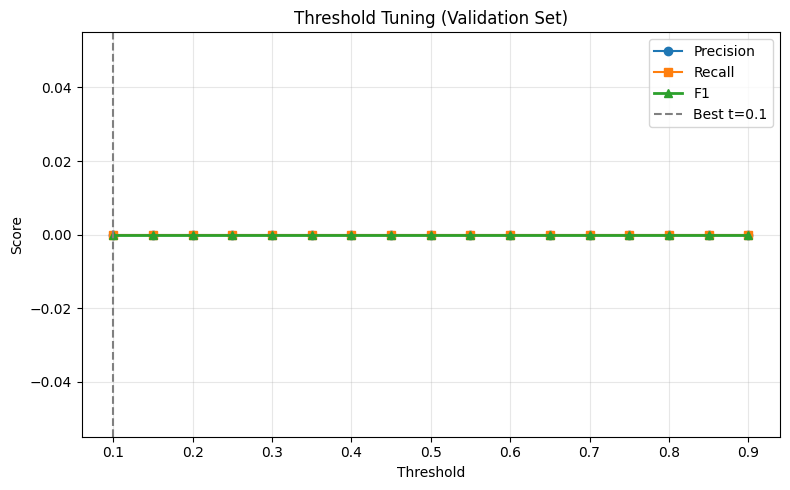

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sweep_df["threshold"], sweep_df["precision"], label="Precision", marker="o")
ax.plot(sweep_df["threshold"], sweep_df["recall"], label="Recall", marker="s")
ax.plot(sweep_df["threshold"], sweep_df["f1"], label="F1", marker="^", linewidth=2)
ax.axvline(best_threshold, color="gray", linestyle="--", label=f"Best t={best_threshold}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Threshold Tuning (Validation Set)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Final Evaluation (Test Set)

In [12]:
from dataclasses import asdict
import numpy as np

def clean_filter_result(fr):
    data = asdict(fr)

    cleaned = {
        k:
        int(v) if isinstance(v, np.integer)
        else float(v) if isinstance(v, np.floating)
        else v
        for k, v in data.items()
    }

    return type(fr)(**cleaned)



test_decisions = clf.predict_batch(test_df["question"].tolist(), test_df["answer"].tolist())
test_preds = [d.confidence >= best_threshold for d in test_decisions]
test_labels = test_df["label"].tolist()

learned_result = evaluator.evaluate(test_preds, test_labels)
baseline_result = evaluator.compute_no_filter_baseline(test_labels)

baseline_result = clean_filter_result(baseline_result)
learned_result = clean_filter_result(learned_result)

comparison = evaluator.compare(
    {"No Filter": baseline_result, "Learned Filter": learned_result},
    save_path="./results/filter_comparison.json",
)
pd.DataFrame(comparison).set_index("strategy").round(4)

INFO:src.filtering.filter_evaluator:Evaluation (n=1742): P=0.000 R=0.000 F1=0.000 Acc=0.500 RejR=1.000
INFO:src.filtering.filter_evaluator:Evaluation (n=1742): P=0.500 R=1.000 F1=0.667 Acc=0.500 RejR=0.000
INFO:src.filtering.filter_evaluator:Comparison table saved to results/filter_comparison.json


,precision,recall,f1,accuracy,rejection_precision,rejection_recall,rejection_rate,tp,tn,fp,fn
strategy,,,,,,,,,,,
No Filter,0.5,1.0,0.6667,0.5,0.0,0.0,0.0,871,0,871,0
Learned Filter,0.0,0.0,0.0000,0.5,0.5,1.0,1.0,0,871,0,871


## 5. Error Analysis

In [13]:
test_df = test_df.copy()
test_df["predicted"] = test_preds
test_df["confidence"] = [d.confidence for d in test_decisions]

fp = test_df[(test_df["label"] == 0) & (test_df["predicted"] == True)]
fn = test_df[(test_df["label"] == 1) & (test_df["predicted"] == False)]
print(f"False Positives (hallucinations accepted): {len(fp)}")
print(f"False Negatives (correct answers rejected): {len(fn)}")
print(f"\nSample False Positives:")
for _, row in fp.head(3).iterrows():
    print(f"  [{row['id']}] conf={row['confidence']:.3f}: {row['answer'][:120]}...")
print(f"\nSample False Negatives:")
for _, row in fn.head(3).iterrows():
    print(f"  [{row['id']}] conf={row['confidence']:.3f}: {row['answer'][:120]}...")

False Positives (hallucinations accepted): 0
False Negatives (correct answers rejected): 871

Sample False Positives:

Sample False Negatives:
  [asqa_8] conf=nan: The third book in the "Harry Potter" series Harry Potter and the Prisoner of Azkaban was published in the UK, US and Can...
  [asqa_12] conf=nan: Between 2013 and 2018, there have been three attorney general for new jersey. From 2013-2016, this position was held by ...
  [asqa_14] conf=nan: Although the chronological limits of this period are open to debate, the period of Enlightenment in Europe is said to ha...


## 6. Apply to Real RAG Outputs

In [14]:
rag_df = pd.read_csv("../results/asqa_normal_rag_predictions.csv")
rag_decisions = clf.predict_batch(rag_df["question"].tolist(), rag_df["predicted_answer"].tolist())
rag_df["filter_accept"] = [d.accept for d in rag_decisions]
rag_df["filter_confidence"] = [round(d.confidence, 4) for d in rag_decisions]

n_accept = rag_df["filter_accept"].sum()
print(f"Accepted: {n_accept}/{len(rag_df)} ({100*n_accept/len(rag_df):.1f}%)")
print(f"Rejected: {len(rag_df)-n_accept}/{len(rag_df)} ({100*(len(rag_df)-n_accept)/len(rag_df):.1f}%)")

rag_df.to_csv("../results/rag_predictions_filtered.csv", index=False)

Accepted: 0/948 (0.0%)
Rejected: 948/948 (100.0%)


## 7. Ablation: Training Data Size

Train on 25%, 50%, 75%, 100% of the data to measure how much labelled data the filter needs.

In [15]:
# fractions = [0.25, 0.50, 0.75, 1.0]
# data_size_rows = []

# for frac in fractions:
#     tag = f"data_{int(frac * 100)}pct"
#     n_samples = int(len(train_df) * frac)
#     subset = train_df.sample(n=n_samples, random_state=SEED).reset_index(drop=True)
#     out_dir = Path(f"../models/ablations/{tag}")

#     if out_dir.exists() and (out_dir / "config.json").exists():
#         print(f"  {tag}: model exists, skipping training.")
#     else:
#         print(f"  Training {tag} ({n_samples} samples)...")
#         train_classifier(subset, val_df, output_dir=str(out_dir))

#     abl_clf = AnswerQualityClassifier(str(out_dir))
#     # find best threshold on val
#     abl_decisions = abl_clf.predict_batch(val_df["question"].tolist(), val_df["answer"].tolist())
#     abl_conf = [d.confidence for d in abl_decisions]
#     best_abl_f1, best_abl_t = 0.0, 0.5
#     for t in np.arange(0.1, 0.95, 0.05):
#         preds = [c >= t for c in abl_conf]
#         r = evaluator.evaluate(preds, val_df["label"].tolist())
#         if r.f1 > best_abl_f1:
#             best_abl_f1 = r.f1
#             best_abl_t = round(float(t), 2)
#     # evaluate on test
#     test_dec = abl_clf.predict_batch(test_df["question"].tolist(), test_df["answer"].tolist())
#     test_p = [d.confidence >= best_abl_t for d in test_dec]
#     r = evaluator.evaluate(test_p, test_df["label"].tolist())
#     data_size_rows.append({"fraction": frac, "n_train": n_samples, "threshold": best_abl_t,
#                            "f1": r.f1, "precision": r.precision, "recall": r.recall, "accuracy": r.accuracy})
#     print(f"  {tag}: F1={r.f1:.4f} Acc={r.accuracy:.4f} (t={best_abl_t})")

# ds_df = pd.DataFrame(data_size_rows)
# ds_df

In [16]:
# fig, ax = plt.subplots(figsize=(8, 5))
# ax.plot(ds_df["fraction"] * 100, ds_df["f1"], marker="o", label="F1", linewidth=2)
# ax.plot(ds_df["fraction"] * 100, ds_df["accuracy"], marker="s", label="Accuracy")
# ax.set_xlabel("Training Data (%)")
# ax.set_ylabel("Score")
# ax.set_title("Ablation: Training Data Size")
# ax.legend()
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

## 8. Ablation: Max Sequence Length

Compare max_length 256, 384, 512 to measure the trade-off between speed and accuracy.

In [17]:
# max_lengths = [256, 384, 512]
# ml_rows = []

# for ml in max_lengths:
#     tag = f"maxlen_{ml}"
#     out_dir = Path(f"../models/ablations/{tag}")

#     if out_dir.exists() and (out_dir / "config.json").exists():
#         print(f"  {tag}: model exists, skipping training.")
#     else:
#         print(f"  Training {tag}...")
#         train_classifier(
#             train_df, val_df,
#             output_dir=str(out_dir),
#             config_overrides={"max_length": ml},
#         )

#     abl_clf = AnswerQualityClassifier(str(out_dir))
#     abl_clf.max_length = ml
#     # find best threshold on val
#     abl_decisions = abl_clf.predict_batch(val_df["question"].tolist(), val_df["answer"].tolist())
#     abl_conf = [d.confidence for d in abl_decisions]
#     best_abl_f1, best_abl_t = 0.0, 0.5
#     for t in np.arange(0.1, 0.95, 0.05):
#         preds = [c >= t for c in abl_conf]
#         r = evaluator.evaluate(preds, val_df["label"].tolist())
#         if r.f1 > best_abl_f1:
#             best_abl_f1 = r.f1
#             best_abl_t = round(float(t), 2)
#     # evaluate on test
#     test_dec = abl_clf.predict_batch(test_df["question"].tolist(), test_df["answer"].tolist())
#     test_p = [d.confidence >= best_abl_t for d in test_dec]
#     r = evaluator.evaluate(test_p, test_df["label"].tolist())
#     ml_rows.append({"max_length": ml, "threshold": best_abl_t,
#                     "f1": r.f1, "precision": r.precision, "recall": r.recall, "accuracy": r.accuracy})
#     print(f"  {tag}: F1={r.f1:.4f} Acc={r.accuracy:.4f} (t={best_abl_t})")

# ml_df = pd.DataFrame(ml_rows)
# ml_df

## 9. Ablation: Model Size

Compare DeBERTa-v3-small (44M), base (86M), and large (304M) to measure
the effect of parametric knowledge on closed-book answer verification.

In [18]:
# model_variants = [
#     ("microsoft/deberta-v3-small", "deberta_small"),
#     ("microsoft/deberta-v3-base", "deberta_base"),
#     ("microsoft/deberta-v3-large", "deberta_large"),
# ]
# model_rows = []

# for model_id, tag in model_variants:
#     out_dir = Path(f"../models/ablations/{tag}")

#     if out_dir.exists() and (out_dir / "config.json").exists():
#         print(f"  {tag}: model exists, skipping training.")
#     else:
#         print(f"  Training {tag} ({model_id})...")
#         train_classifier(
#             train_df, val_df,
#             output_dir=str(out_dir),
#             config_overrides={"model_name": model_id},
#         )

#     abl_clf = AnswerQualityClassifier(str(out_dir))
#     abl_decisions = abl_clf.predict_batch(
#         val_df["question"].tolist(), val_df["answer"].tolist()
#     )
#     abl_conf = [d.confidence for d in abl_decisions]
#     best_abl_f1, best_abl_t = 0.0, 0.5
#     for t in np.arange(0.1, 0.95, 0.05):
#         preds = [c >= t for c in abl_conf]
#         r = evaluator.evaluate(preds, val_df["label"].tolist())
#         if r.f1 > best_abl_f1:
#             best_abl_f1 = r.f1
#             best_abl_t = round(float(t), 2)

#     test_dec = abl_clf.predict_batch(
#         test_df["question"].tolist(), test_df["answer"].tolist()
#     )
#     test_p = [d.confidence >= best_abl_t for d in test_dec]
#     r = evaluator.evaluate(test_p, test_df["label"].tolist())
#     model_rows.append({
#         "model": tag, "threshold": best_abl_t,
#         "f1": r.f1, "precision": r.precision, "recall": r.recall,
#         "accuracy": r.accuracy, "rejection_recall": r.rejection_recall,
#         "rejection_rate": r.rejection_rate,
#     })
#     print(f"  {tag}: F1={r.f1:.4f} Acc={r.accuracy:.4f} (t={best_abl_t})")

# model_df = pd.DataFrame(model_rows)
# model_df

## 10. NLI Zero-Shot Filter (no training)

Use a pre-trained NLI model as a zero-shot answer quality filter.
Frames the task as: "Does the question entail the answer?"

In [19]:
from src.filtering.nli_filter import NLIAnswerFilter

nli_filter = NLIAnswerFilter(model_name="cross-encoder/nli-deberta-v3-small")

nli_val_decisions = nli_filter.predict_batch(
    val_df["question"].tolist(), val_df["answer"].tolist()
)
nli_val_conf = [d.confidence for d in nli_val_decisions]
nli_val_labels = val_df["label"].tolist()

nli_sweep = []
for t in np.arange(0.1, 0.95, 0.05):
    preds = [c >= t for c in nli_val_conf]
    r = evaluator.evaluate(preds, nli_val_labels)
    nli_sweep.append({
        "threshold": round(float(t), 2),
        "f1": r.f1, "precision": r.precision, "recall": r.recall,
        "accuracy": r.accuracy,
        "rejection_recall": r.rejection_recall,
        "rejection_rate": r.rejection_rate,
    })

nli_sweep_df = pd.DataFrame(nli_sweep)
nli_best_row = nli_sweep_df.loc[nli_sweep_df["f1"].idxmax()]
nli_best_threshold = nli_best_row["threshold"]
print(f"NLI Best threshold: {nli_best_threshold} (F1={nli_best_row['f1']:.4f})")

nli_test_decisions = nli_filter.predict_batch(
    test_df["question"].tolist(), test_df["answer"].tolist()
)
nli_test_preds = [d.confidence >= nli_best_threshold for d in nli_test_decisions]
nli_result = evaluator.evaluate(nli_test_preds, test_df["label"].tolist())
nli_result = clean_filter_result(nli_result)

nli_comparison = evaluator.compare(
    {
        "No Filter": baseline_result,
        "Learned Filter": learned_result,
        "NLI Zero-Shot": nli_result,
    },
    save_path="../results/filter_comparison_with_nli.json",
)
pd.DataFrame(nli_comparison).set_index("strategy").round(4)

INFO:httpx:HTTP Request: HEAD https://huggingface.co/cross-encoder/nli-deberta-v3-small/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/cross-encoder/nli-deberta-v3-small/fa2804872c3b4bd748f38c0185cc85775361e735/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/resolve-cache/models/cross-encoder/nli-deberta-v3-small/fa2804872c3b4bd748f38c0185cc85775361e735/config.json "HTTP/1.1 200 OK"


config.json: 0.00B [00:00, ?B/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/cross-encoder/nli-deberta-v3-small/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/cross-encoder/nli-deberta-v3-small/fa2804872c3b4bd748f38c0185cc85775361e735/tokenizer_config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/resolve-cache/models/cross-encoder/nli-deberta-v3-small/fa2804872c3b4bd748f38c0185cc85775361e735/tokenizer_config.json "HTTP/1.1 200 OK"


tokenizer_config.json: 0.00B [00:00, ?B/s]

INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/cross-encoder/nli-deberta-v3-small/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/cross-encoder/nli-deberta-v3-small/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/cross-encoder/nli-deberta-v3-small/resolve/main/spm.model "HTTP/1.1 302 Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/cross-encoder/nli-deberta-v3-small/xet-read-token/fa2804872c3b4bd748f38c0185cc85775361e735 "HTTP/1.1 200 OK"


...

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: cross-encoder/nli-deberta-v3-small
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
INFO:src.filtering.nli_filter:NLIAnswerFilter loaded: cross-encoder/nli-deberta-v3-small (threshold=0.50, device=cuda)
INFO:src.filtering.filter_evaluator:Evaluation (n=1394): P=0.562 R=0.013 F1=0.025 Acc=0.501 RejR=0.989
INFO:src.filtering.filter_evaluator:Evaluation (n=1394): P=0.538 R=0.010 F1=0.020 Acc=0.501 RejR=0.991
INFO:src.filtering.filter_evaluator:Evaluation (n=1394): P=0.538 R=0.010 F1=0.020 Acc=0.501 RejR=0.991
INFO:src.filtering.filter_evaluator:Evaluation (n=1394): P=0.500 R=0.009 F1=0.017 Acc=0.500 RejR=0.991
INFO:src.filtering.filter_evaluator:Evaluation (n=1394): P=0.545 R=0.009 F1=0.017 Acc=0.501 RejR=0.992
INFO

NLI Best threshold: 0.1 (F1=0.0252)


INFO:src.filtering.filter_evaluator:Evaluation (n=1742): P=0.560 R=0.016 F1=0.031 Acc=0.502 RejR=0.986
INFO:src.filtering.filter_evaluator:Comparison table saved to ../results/filter_comparison_with_nli.json


,precision,recall,f1,accuracy,rejection_precision,rejection_recall,rejection_rate,tp,tn,fp,fn
strategy,,,,,,,,,,,
No Filter,0.50,1.0000,0.6667,0.5000,0.0000,0.0000,0.0000,871,0,871,0
Learned Filter,0.00,0.0000,0.0000,0.5000,0.5000,1.0000,1.0000,0,871,0,871
NLI Zero-Shot,0.56,0.0161,0.0312,0.5017,0.5009,0.9874,0.9856,14,860,11,857


## 11. Ensemble Filter (DeBERTa + NLI + Lexical features)

Combine the learned DeBERTa confidence, NLI entailment score, and
lexical features (token overlap, answer length) into a logistic
regression meta-classifier.

In [20]:
from src.filtering.ensemble_filter import EnsembleFilter

ensemble = EnsembleFilter(
    deberta_clf=clf,
    nli_filter=nli_filter,
)

train_metrics = ensemble.fit(
    train_df["question"].tolist(),
    train_df["answer"].tolist(),
    train_df["label"].tolist(),
)
print(f"Ensemble train metrics: {train_metrics}")

ensemble_val_decisions = ensemble.predict_batch(
    val_df["question"].tolist(), val_df["answer"].tolist()
)
ensemble_val_conf = [d.confidence for d in ensemble_val_decisions]

ens_sweep = []
for t in np.arange(0.1, 0.95, 0.05):
    preds = [c >= t for c in ensemble_val_conf]
    r = evaluator.evaluate(preds, val_df["label"].tolist())
    ens_sweep.append({
        "threshold": round(float(t), 2),
        "f1": r.f1, "precision": r.precision, "recall": r.recall,
        "accuracy": r.accuracy,
    })

ens_sweep_df = pd.DataFrame(ens_sweep)
ens_best_row = ens_sweep_df.loc[ens_sweep_df["f1"].idxmax()]
ens_best_threshold = ens_best_row["threshold"]
print(f"Ensemble best threshold: {ens_best_threshold} (F1={ens_best_row['f1']:.4f})")

ensemble_test_decisions = ensemble.predict_batch(
    test_df["question"].tolist(), test_df["answer"].tolist()
)
ens_test_preds = [d.confidence >= ens_best_threshold for d in ensemble_test_decisions]
ensemble_result = evaluator.evaluate(ens_test_preds, test_df["label"].tolist())
ensemble_result = clean_filter_result(ensemble_result)

ensemble.save("../models/ensemble_filter")


all_comparison = evaluator.compare(
    {
        "No Filter": baseline_result,
        "Learned Filter": learned_result,
        "NLI Zero-Shot": nli_result,
        "Ensemble": ensemble_result,
    },
    save_path="../results/filter_comparison_all.json",
)
pd.DataFrame(all_comparison).set_index("strategy").round(4)

INFO:src.filtering.ensemble_filter:Extracting ensemble features for 5570 samples...
INFO:src.filtering.ensemble_filter:Ensemble train metrics: {'train_accuracy': 0.9700179533213644, 'train_f1': 0.9701412479885572, 'train_precision': 0.9661680911680912, 'train_recall': 0.9741472172351885}


Ensemble train metrics: {'train_accuracy': 0.9700179533213644, 'train_f1': 0.9701412479885572, 'train_precision': 0.9661680911680912, 'train_recall': 0.9741472172351885}


INFO:src.filtering.filter_evaluator:Evaluation (n=1394): P=0.507 R=0.937 F1=0.658 Acc=0.514 RejR=0.077
INFO:src.filtering.filter_evaluator:Evaluation (n=1394): P=0.508 R=0.897 F1=0.649 Acc=0.514 RejR=0.118
INFO:src.filtering.filter_evaluator:Evaluation (n=1394): P=0.508 R=0.851 F1=0.636 Acc=0.514 RejR=0.163
INFO:src.filtering.filter_evaluator:Evaluation (n=1394): P=0.511 R=0.812 F1=0.627 Acc=0.518 RejR=0.206
INFO:src.filtering.filter_evaluator:Evaluation (n=1394): P=0.516 R=0.762 F1=0.615 Acc=0.523 RejR=0.261
INFO:src.filtering.filter_evaluator:Evaluation (n=1394): P=0.517 R=0.696 F1=0.593 Acc=0.522 RejR=0.326
INFO:src.filtering.filter_evaluator:Evaluation (n=1394): P=0.517 R=0.643 F1=0.573 Acc=0.522 RejR=0.379
INFO:src.filtering.filter_evaluator:Evaluation (n=1394): P=0.517 R=0.572 F1=0.543 Acc=0.519 RejR=0.446
INFO:src.filtering.filter_evaluator:Evaluation (n=1394): P=0.516 R=0.514 F1=0.515 Acc=0.516 RejR=0.502
INFO:src.filtering.filter_evaluator:Evaluation (n=1394): P=0.522 R=0.452 

Ensemble best threshold: 0.1 (F1=0.6583)


INFO:src.filtering.filter_evaluator:Evaluation (n=1742): P=0.512 R=0.951 F1=0.666 Acc=0.523 RejR=0.072
INFO:src.filtering.ensemble_filter:Ensemble filter saved to ../models/ensemble_filter
INFO:src.filtering.filter_evaluator:Comparison table saved to ../results/filter_comparison_all.json


,precision,recall,f1,accuracy,rejection_precision,rejection_recall,rejection_rate,tp,tn,fp,fn
strategy,,,,,,,,,,,
No Filter,0.5000,1.0000,0.6667,0.5000,0.0000,0.0000,0.0000,871,0,871,0
Learned Filter,0.0000,0.0000,0.0000,0.5000,0.5000,1.0000,1.0000,0,871,0,871
NLI Zero-Shot,0.5600,0.0161,0.0312,0.5017,0.5009,0.9874,0.9856,14,860,11,857
Ensemble,0.5124,0.9506,0.6659,0.5230,0.6587,0.0953,0.0723,828,83,788,43


## 12. Results Summary

In [21]:
print("=== FINAL RESULTS (all 6 required metrics) ===")
print(f"Trained on: {len(train_df)} samples, Evaluated on: {len(test_df)} samples")

strategies = [
    ("No Filter", baseline_result, "-"),
    ("Learned (small)", learned_result, best_threshold),
    ("NLI Zero-Shot", nli_result, nli_best_threshold),
    ("Ensemble", ensemble_result, ens_best_threshold),
]

header = (
    f"{'Strategy':<18} {'t':>5} {'P':>6} {'R':>6} {'F1':>6} "
    f"{'Acc':>6} {'RejR':>6} {'RejRate':>8}"
)
print(f"\n{header}")
print("-" * len(header))
for name, r, t in strategies:
    t_str = f"{t}" if isinstance(t, str) else f"{t:.2f}"
    print(
        f"{name:<18} {t_str:>5} {r.precision:>6.3f} {r.recall:>6.3f} "
        f"{r.f1:>6.3f} {r.accuracy:>6.3f} "
        f"{r.rejection_recall:>6.3f} {r.rejection_rate:>8.3f}"
    )

print(f"\nRAG outputs: {n_accept}/{len(rag_df)} accepted ({100*n_accept/len(rag_df):.1f}%)")

=== FINAL RESULTS (all 6 required metrics) ===
Trained on: 5570 samples, Evaluated on: 1742 samples

Strategy               t      P      R     F1    Acc   RejR  RejRate
--------------------------------------------------------------------
No Filter              -  0.500  1.000  0.667  0.500  0.000    0.000
Learned (small)     0.10  0.000  0.000  0.000  0.500  1.000    1.000
NLI Zero-Shot       0.10  0.560  0.016  0.031  0.502  0.987    0.986
Ensemble            0.10  0.512  0.951  0.666  0.523  0.095    0.072

RAG outputs: 0/948 accepted (0.0%)
